# Togather — Exploratory Data Analysis

**Data:** event requests & supplier quotes (2024)  
**Goal:** understand data quality, distributions, and conversion patterns to inform 2025 strategy.

## 0. Setup

In [ ]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FIGURES = '../outputs/figures/'
RAW     = '../data/raw/'

In [ ]:
def load_requests(path=RAW + 'food_requests.xlsx'):
    """Row 0 is a junk filename row; actual headers are on row 1."""
    df = pd.read_excel(path, header=1)
    df.columns = ['event_request_id', 'created', 'region', 'priority_tag', 'request_budget']
    df['created'] = pd.to_datetime(df['created'], format='mixed')
    df['priority_tag'] = df['priority_tag'].str.strip()
    return df

def load_quotes(path=RAW + 'food_quotes.xlsx'):
    df = pd.read_excel(path)
    df.columns = [
        'quote_id', 'supplier_id', 'event_request_id',
        'quote_created', 'booked', 'supplier_region',
        'quote_price', 'supplier_primary_tag'
    ]
    df['quote_created'] = pd.to_datetime(df['quote_created'], format='mixed')
    df['booked'] = df['booked'].astype(int)
    df['supplier_primary_tag'] = df['supplier_primary_tag'].str.strip()
    return df

requests = load_requests()
quotes   = load_quotes()
print('Requests:', requests.shape)
print('Quotes:  ', quotes.shape)

Requests: (55104, 5)
Quotes:   (218351, 8)


---
## 1. Event Requests — standalone

### 1.1 Schema & data quality

In [ ]:
print(requests.dtypes)
print()
print('Null counts:')
print(requests.isnull().sum())
print()
print('Date range:', requests['created'].min(), '→', requests['created'].max())
print('Unique requests:', requests['event_request_id'].nunique())
requests.head()

event_request_id               str
created             datetime64[us]
region                         str
priority_tag                   str
request_budget               int64
dtype: object

Null counts:
event_request_id       0
created                0
region              1950
priority_tag        6925
request_budget         0
dtype: int64

Date range: 2024-01-01 01:20:58.273000 → 2024-12-31 23:06:16.072000
Unique requests: 55104


,event_request_id,created,region,priority_tag,request_budget
0,5d6a8cc5-05b7-4b80-8d38-bf60d072fc5c,2024-02-03 10:51:53.233,Wales,Pies,400
1,d519f7ad-d538-4423-9c9b-ce8ed48f04e6,2024-05-15 12:58:08.265,NaN,Pizza,650
2,df07ceee-4bf0-4197-823f-864fad21a09d,2024-07-07 13:51:41.912,South East,Asian,1000
3,8edcb7a8-78d0-4d86-beea-1e422f2e886e,2024-01-31 20:04:03.247,East Midlands,Dessert,500
4,3844f2e9-0a64-461f-933e-94f336248381,2024-11-26 17:57:53.830,North West,Chinese,500


In [ ]:
# Duplicates check
print('=== Requests duplicates ===')
print(f'Total rows:              {len(requests):,}')
print(f'Unique event_request_id: {requests["event_request_id"].nunique():,}')
print(f'Duplicate request IDs:   {len(requests) - requests["event_request_id"].nunique():,}')
print()
print('=== Quotes duplicates ===')
print(f'Total rows:       {len(quotes):,}')
print(f'Unique quote_id:  {quotes["quote_id"].nunique():,}')
print(f'Duplicate quotes: {len(quotes) - quotes["quote_id"].nunique():,}')

### 1.2 Monthly request volume

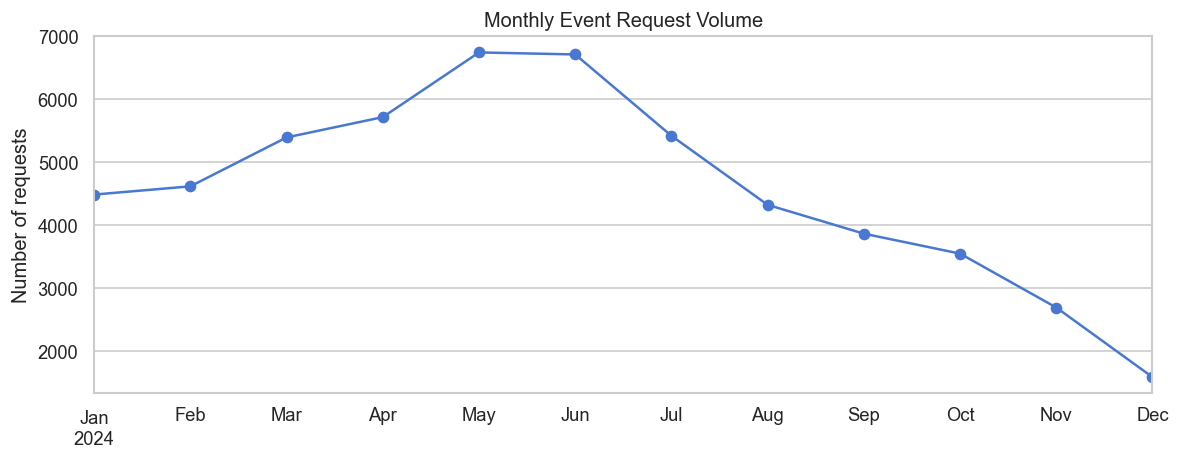

In [ ]:
monthly = requests.set_index('created').resample('ME')['event_request_id'].count()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker='o')
ax.set_title('Monthly Event Request Volume')
ax.set_xlabel('')
ax.set_ylabel('Number of requests')
plt.tight_layout()
plt.savefig(FIGURES + '01_monthly_requests.png')
plt.show()

### 1.3 Regional distribution

Missing region: 1950 (3.5%)


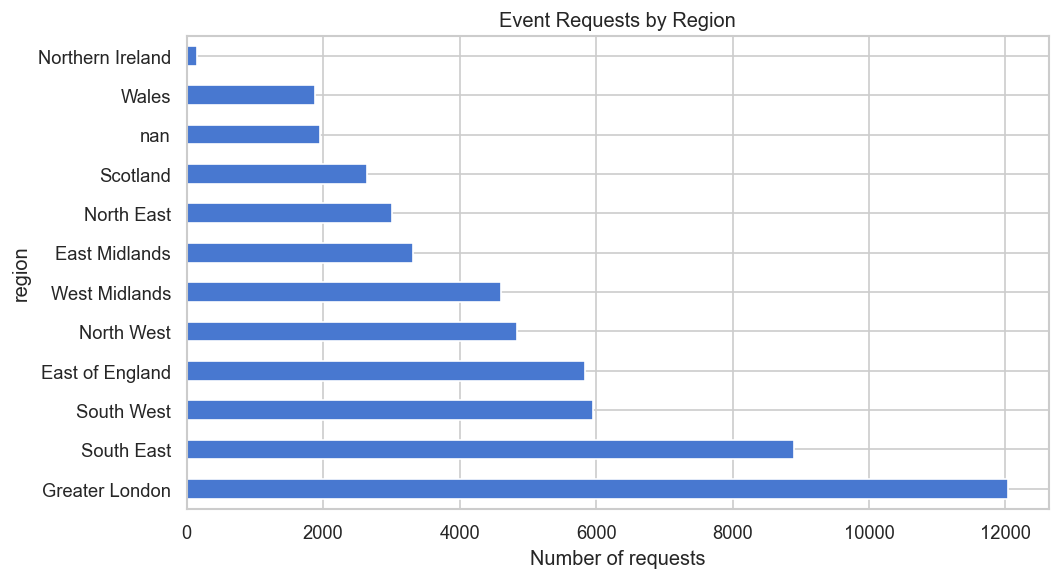

In [ ]:
region_counts = requests['region'].value_counts(dropna=False)
print(f'Missing region: {requests["region"].isnull().sum()} ({requests["region"].isnull().mean():.1%})')

fig, ax = plt.subplots(figsize=(9, 5))
region_counts.plot(kind='barh', ax=ax)
ax.set_title('Event Requests by Region')
ax.set_xlabel('Number of requests')
plt.tight_layout()
plt.savefig(FIGURES + '02_requests_by_region.png')
plt.show()

### 1.4 Priority tag distribution (top 15)

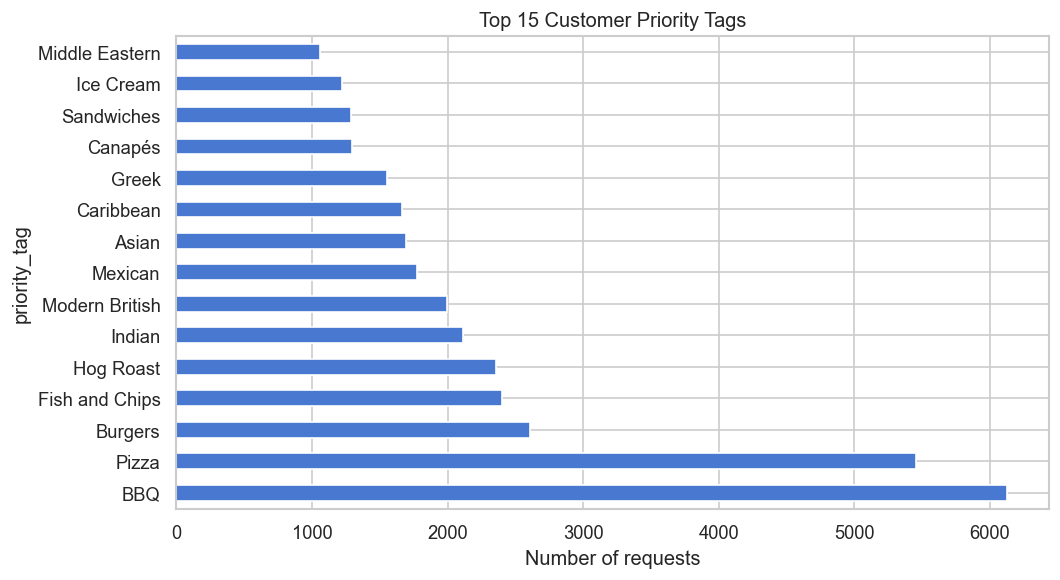

In [ ]:
tag_counts = requests['priority_tag'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
tag_counts.plot(kind='barh', ax=ax)
ax.set_title('Top 15 Customer Priority Tags')
ax.set_xlabel('Number of requests')
plt.tight_layout()
plt.savefig(FIGURES + '03_priority_tags.png')
plt.show()

### 1.5 Budget distribution

In [ ]:
# Skewness of numeric columns
print('=== Skewness ===')
print(f'request_budget skewness: {requests["request_budget"].skew():.2f}')
print()

# Cardinality of categorical columns
print('=== Cardinality (unique values) ===')
for col in ['region', 'priority_tag']:
    print(f'requests.{col}: {requests[col].nunique()} unique values')

count    5.510400e+04
mean     2.088996e+04
std      4.261386e+06
min      1.000000e+00
25%      5.000000e+02
50%      1.000000e+03
75%      1.500000e+03
max      1.000000e+09
Name: request_budget, dtype: float64

Outliers above 99th percentile (£10,000): 416


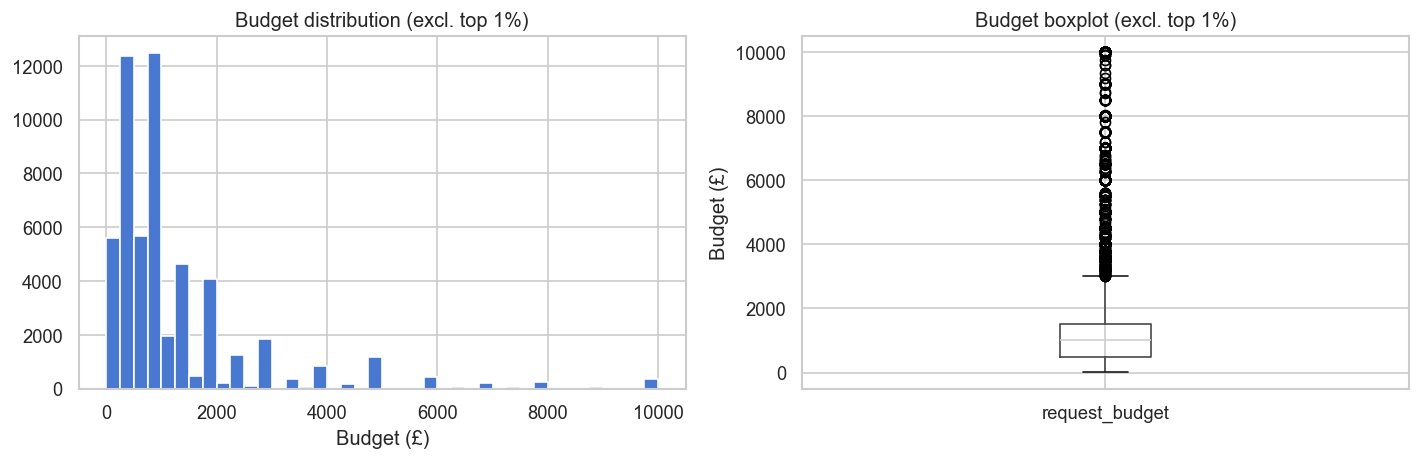

In [ ]:
print(requests['request_budget'].describe().round(2))
p99 = requests['request_budget'].quantile(0.99)
outliers = requests[requests['request_budget'] > p99]
print(f'\nOutliers above 99th percentile (£{p99:,.0f}): {len(outliers)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
requests[requests['request_budget'] <= p99]['request_budget'].hist(bins=40, ax=axes[0])
axes[0].set_title('Budget distribution (excl. top 1%)')
axes[0].set_xlabel('Budget (£)')

requests[requests['request_budget'] <= p99].boxplot(column='request_budget', ax=axes[1])
axes[1].set_title('Budget boxplot (excl. top 1%)')
axes[1].set_ylabel('Budget (£)')

plt.tight_layout()
plt.savefig(FIGURES + '04_budget_distribution.png')
plt.show()

---
## 2. Quotes — standalone

In [ ]:
# Gaps in time series — weeks with unusually low quote activity
weekly_quotes = quotes.set_index('quote_created').resample('W')['quote_id'].count()
mean_vol = weekly_quotes.mean()
gaps = weekly_quotes[weekly_quotes < mean_vol * 0.5]
print(f'Mean weekly quotes: {mean_vol:.0f}')
print(f'Weeks below 50% of mean (potential gaps): {len(gaps)}')
print(gaps)

# Cardinality of quotes categorical columns
print()
print('=== Quotes cardinality ===')
for col in ['supplier_region', 'supplier_primary_tag']:
    print(f'quotes.{col}: {quotes[col].nunique()} unique values')
print(f'quotes.quote_price skewness: {quotes["quote_price"].skew():.2f}')

### 2.1 Schema & data quality

In [ ]:
print(quotes.dtypes)
print()
print('Null counts:')
print(quotes.isnull().sum())
print()
print('Date range:', quotes['quote_created'].min(), '→', quotes['quote_created'].max())
print('Unique quotes:    ', quotes['quote_id'].nunique())
print('Unique suppliers: ', quotes['supplier_id'].nunique())
quotes.head()

quote_id                           str
supplier_id                        str
event_request_id                   str
quote_created           datetime64[us]
booked                           int64
supplier_region                    str
quote_price                    float64
supplier_primary_tag               str
dtype: object

Null counts:
quote_id                   0
supplier_id                0
event_request_id           0
quote_created              0
booked                     0
supplier_region            0
quote_price                0
supplier_primary_tag    2602
dtype: int64

Date range: 2024-01-01 07:12:24.633000 → 2025-04-09 22:37:17.925000
Unique quotes:     218351
Unique suppliers:  1054


,quote_id,supplier_id,event_request_id,quote_created,booked,supplier_region,quote_price,supplier_primary_tag
0,2ccff37a-d5c3-4b50-afaa-399ecdf44e96,8a43fd73-5d8b-48b5-b35f-cb26e3f90afa,2f233531-27ce-4a1f-9fac-0348b96000f2,2024-09-05 17:30:11.146,0,East Midlands,1050.00,Fusion
1,bb2ed7f3-41ce-4607-9634-b5a4469c1948,1e12b191-7b76-4101-93d9-fed6ccb2af5f,2f233531-27ce-4a1f-9fac-0348b96000f2,2024-09-05 15:05:57.940,0,East Midlands,1260.00,Burgers
2,ac350c3b-2a6f-42f9-a4c1-50c81ef0d823,11408500-38e4-440b-b90c-1e5584db411a,eaeb6095-9c25-4b83-a3f6-6a79fd3765b3,2024-05-01 08:10:20.729,0,South East,730.32,Crêpes
3,38f1929c-4f02-4343-9d11-ff3588ec2f26,3ebefda3-56d4-458b-a8ad-5009ed66250f,eaeb6095-9c25-4b83-a3f6-6a79fd3765b3,2024-05-01 21:39:24.320,0,Greater London,977.90,Pizza
4,50bf4ceb-7035-4a89-976c-7bb20d59a0b1,52086a31-d824-4f50-9dca-d214872d1342,eaeb6095-9c25-4b83-a3f6-6a79fd3765b3,2024-05-01 08:12:15.427,0,South East,486.88,Ice Cream


### 2.2 Overall booking rate

In [ ]:
booking_rate = quotes['booked'].mean()
print(f'Overall quote → booking rate: {booking_rate:.2%}')
print(quotes['booked'].value_counts())

Overall quote → booking rate: 1.94%
booked
0    214112
1      4239
Name: count, dtype: int64


### 2.3 Quotes per supplier

count    1054.0
mean      207.2
std       523.3
min         1.0
25%         4.0
50%        25.0
75%       132.0
max      5587.0
Name: quote_id, dtype: float64

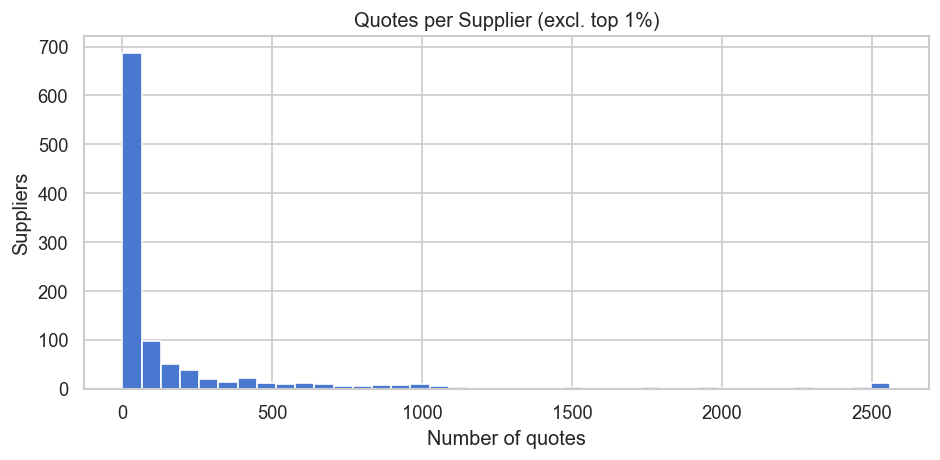

In [ ]:
quotes_per_supplier = quotes.groupby('supplier_id')['quote_id'].count()
print(quotes_per_supplier.describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
quotes_per_supplier.clip(upper=quotes_per_supplier.quantile(0.99)).hist(bins=40, ax=ax)
ax.set_title('Quotes per Supplier (excl. top 1%)')
ax.set_xlabel('Number of quotes')
ax.set_ylabel('Suppliers')
plt.tight_layout()
plt.savefig(FIGURES + '05_quotes_per_supplier.png')
plt.show()

### 2.4 Supplier regional distribution

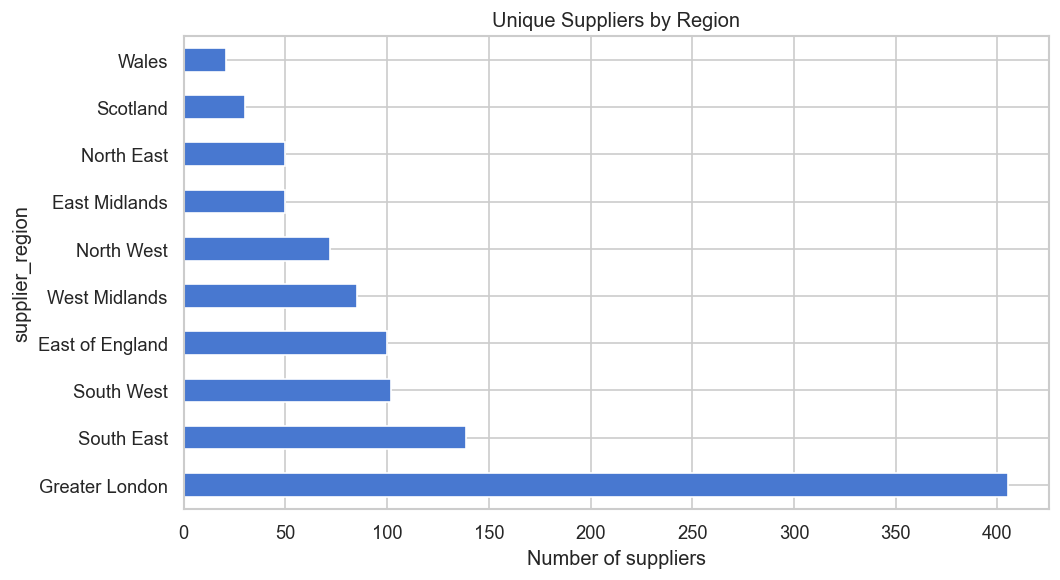

In [ ]:
supplier_region = quotes.drop_duplicates('supplier_id')['supplier_region'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
supplier_region.plot(kind='barh', ax=ax)
ax.set_title('Unique Suppliers by Region')
ax.set_xlabel('Number of suppliers')
plt.tight_layout()
plt.savefig(FIGURES + '06_suppliers_by_region.png')
plt.show()

### 2.5 Supplier primary tag distribution

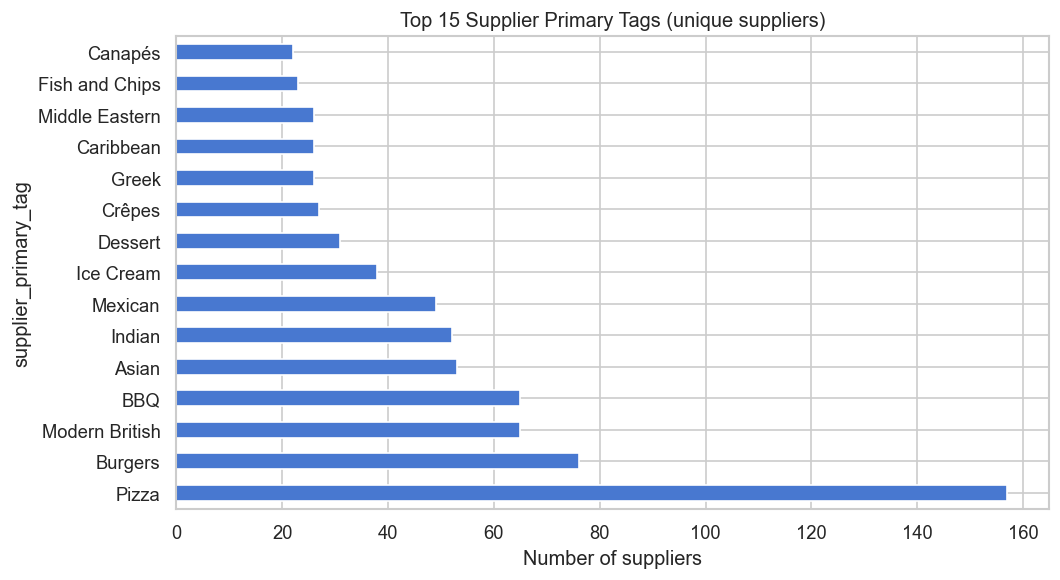

In [ ]:
supplier_tags = quotes.drop_duplicates('supplier_id')['supplier_primary_tag'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
supplier_tags.plot(kind='barh', ax=ax)
ax.set_title('Top 15 Supplier Primary Tags (unique suppliers)')
ax.set_xlabel('Number of suppliers')
plt.tight_layout()
plt.savefig(FIGURES + '07_supplier_tags.png')
plt.show()

---
## 2.7 Continuous variables — correlation, pairplot & grouped boxplot

In [ ]:
# Build a combined table for continuous variable analysis
_combined_cont = quotes.merge(
    requests[['event_request_id', 'request_budget']],
    on='event_request_id', how='left'
)[['request_budget', 'quote_price', 'booked']].dropna()

# --- Correlation heatmap ---
corr = _combined_cont[['request_budget', 'quote_price']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation: Budget vs Quote Price')
plt.tight_layout()
plt.savefig(FIGURES + '15_correlation_heatmap.png')
plt.show()

In [ ]:
# --- Pairplot: continuous variables coloured by booked ---
p99_b = _combined_cont['request_budget'].quantile(0.99)
p99_q = _combined_cont['quote_price'].quantile(0.99)
_plot_df = _combined_cont[
    (_combined_cont['request_budget'] <= p99_b) &
    (_combined_cont['quote_price'] <= p99_q)
].copy()
_plot_df['booked'] = _plot_df['booked'].map({1: 'Booked', 0: 'Not booked'})

g = sns.pairplot(
    _plot_df,
    vars=['request_budget', 'quote_price'],
    hue='booked',
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde'
)
g.figure.suptitle('Pairplot: Budget vs Quote Price (coloured by booking)', y=1.02)
g.figure.savefig(FIGURES + '16_pairplot_continuous.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- Grouped boxplot: quote price by supplier region ---
p99_q2 = quotes['quote_price'].quantile(0.99)
_box_df = quotes[quotes['quote_price'] <= p99_q2].copy()

order = _box_df.groupby('supplier_region')['quote_price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=_box_df, x='supplier_region', y='quote_price', order=order, ax=ax)
ax.set_title('Quote Price Distribution by Supplier Region (excl. top 1%)')
ax.set_xlabel('Supplier Region')
ax.set_ylabel('Quote Price (£)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES + '17_quote_price_by_region.png')
plt.show()

### 2.6 Quote price distribution & booked vs not-booked

count     218351.00
mean        2097.93
std         4021.33
min            0.00
25%         1025.03
50%         1485.25
75%         2255.00
max      1024996.93
Name: quote_price, dtype: float64


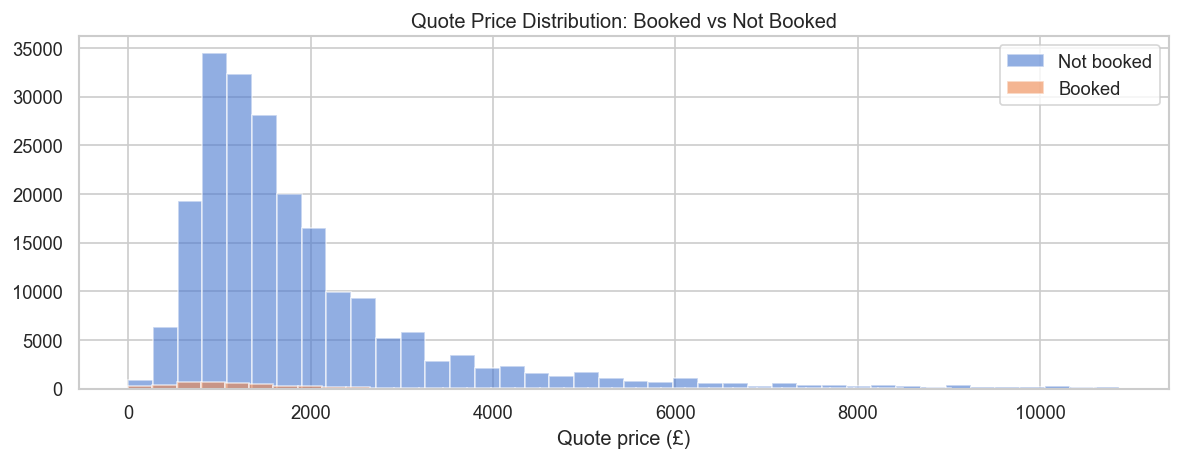


Median price — booked vs not booked:
booked
Not booked    1487.28
Booked        1155.00
Name: quote_price, dtype: float64


In [ ]:
print(quotes['quote_price'].describe().round(2))

p99_price = quotes['quote_price'].quantile(0.99)
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in quotes[quotes['quote_price'] <= p99_price].groupby('booked'):
    grp['quote_price'].hist(bins=40, alpha=0.6, ax=ax, label='Booked' if label else 'Not booked')
ax.set_title('Quote Price Distribution: Booked vs Not Booked')
ax.set_xlabel('Quote price (£)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES + '08_quote_price_booked.png')
plt.show()

print('\nMedian price — booked vs not booked:')
print(quotes.groupby('booked')['quote_price'].median().rename({0: 'Not booked', 1: 'Booked'}))

---
## 3. Combined Analysis

In [ ]:
# Left join: keep all requests, attach their quotes
combined = requests.merge(quotes, on='event_request_id', how='left')
print('Combined shape:', combined.shape)
combined.head()

Combined shape: (235681, 12)


,event_request_id,created,region,priority_tag,request_budget,quote_id,supplier_id,quote_created,booked,supplier_region,quote_price,supplier_primary_tag
0,5d6a8cc5-05b7-4b80-8d38-bf60d072fc5c,2024-02-03 10:51:53.233,Wales,Pies,400,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,d519f7ad-d538-4423-9c9b-ce8ed48f04e6,2024-05-15 12:58:08.265,NaN,Pizza,650,7017f576-dffe-46a4-b352-62cb1c99f27e,5eb3ca3a-735b-477d-8d34-d0d74a217a80,2024-05-17 07:45:54.924,0.0,West Midlands,1025.00,Pizza
2,df07ceee-4bf0-4197-823f-864fad21a09d,2024-07-07 13:51:41.912,South East,Asian,1000,76f13c1c-cb3d-49c8-88c4-385ef7d06065,0c813502-1daa-4624-9fad-866760b2388a,2024-07-10 11:27:25.620,0.0,South West,1004.50,Asian
3,df07ceee-4bf0-4197-823f-864fad21a09d,2024-07-07 13:51:41.912,South East,Asian,1000,3c78e823-0be3-4a53-9c88-b8a502e6edf1,942cecaa-7096-4b71-b7dc-3cfad4434bab,2024-07-07 20:08:31.455,0.0,East Midlands,984.00,Burgers
4,8edcb7a8-78d0-4d86-beea-1e422f2e886e,2024-01-31 20:04:03.247,East Midlands,Dessert,500,13d2d079-dba9-4137-b4c6-9cbb85c3ef9f,6797b7bb-d71a-4890-a95f-45ff0b0462a3,2024-01-31 21:13:14.309,0.0,East Midlands,542.65,Crêpes


### 3.1 Coverage — requests with and without quotes

In [ ]:
has_quote = combined.groupby('event_request_id')['quote_id'].count().rename('quote_count')
requests_with_quotes = (has_quote > 0).mean()
print(f'Requests that received ≥1 quote: {requests_with_quotes:.1%}')
print(f'Requests with ZERO quotes:       {1 - requests_with_quotes:.1%}')

# Unmet demand by region
unmet = combined[combined['quote_id'].isnull()].groupby('region').size().sort_values(ascending=False)
print('\nUnmet requests by region:')
print(unmet)

Requests that received ≥1 quote: 68.5%
Requests with ZERO quotes:       31.5%

Unmet requests by region:
region
South West          2298
Greater London      2251
South East          2236
North West          1746
East of England     1703
West Midlands       1573
Scotland            1541
East Midlands       1279
North East          1068
Wales                845
Northern Ireland     124
dtype: int64


### 3.2 Customer region vs supplier region (cross-region quoting)

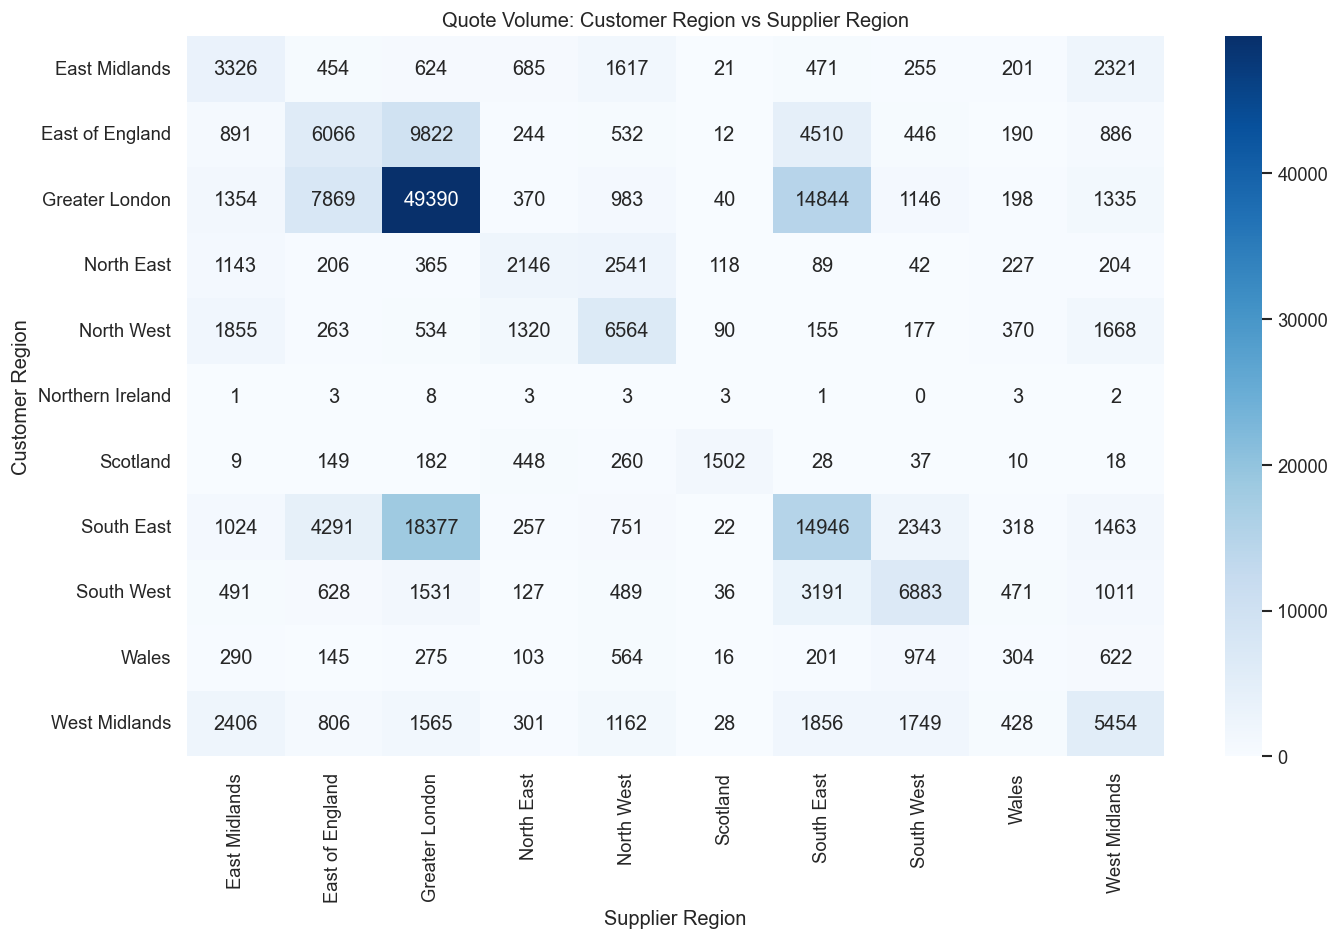

In [ ]:
region_cross = combined.dropna(subset=['region', 'supplier_region']).groupby(
    ['region', 'supplier_region']
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(region_cross, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Quote Volume: Customer Region vs Supplier Region')
ax.set_xlabel('Supplier Region')
ax.set_ylabel('Customer Region')
plt.tight_layout()
plt.savefig(FIGURES + '09_region_cross.png')
plt.show()

### 3.3 Budget vs quote price delta

Quotes above customer budget: 56.9%
Median delta (quote - budget): £38


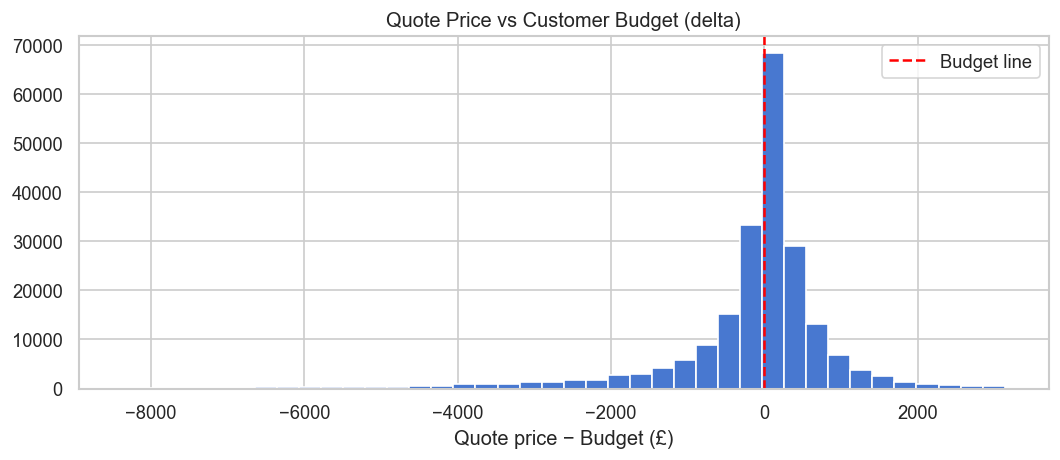

In [ ]:
priced = combined.dropna(subset=['request_budget', 'quote_price']).copy()
priced['price_vs_budget'] = priced['quote_price'] - priced['request_budget']
priced['above_budget'] = priced['price_vs_budget'] > 0

print(f'Quotes above customer budget: {priced["above_budget"].mean():.1%}')
print(f'Median delta (quote - budget): £{priced["price_vs_budget"].median():,.0f}')

p1, p99 = priced['price_vs_budget'].quantile([0.01, 0.99])
fig, ax = plt.subplots(figsize=(9, 4))
priced[priced['price_vs_budget'].between(p1, p99)]['price_vs_budget'].hist(bins=40, ax=ax)
ax.axvline(0, color='red', linestyle='--', label='Budget line')
ax.set_title('Quote Price vs Customer Budget (delta)')
ax.set_xlabel('Quote price − Budget (£)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES + '10_price_vs_budget.png')
plt.show()

### 3.4 Priority tag vs supplier primary tag match rate

In [ ]:
tagged = combined.dropna(subset=['priority_tag', 'supplier_primary_tag'])
match_rate = (tagged['priority_tag'] == tagged['supplier_primary_tag']).mean()
print(f'Tag match rate (customer priority == supplier primary): {match_rate:.1%}')

# Booked rate when tags match vs don't match
booked_by_match = tagged.groupby(
    tagged['priority_tag'] == tagged['supplier_primary_tag']
)['booked'].mean().rename({True: 'Tag match', False: 'Tag mismatch'})
print('\nBooking rate by tag match:')
print(booked_by_match)

Tag match rate (customer priority == supplier primary): 18.9%

Booking rate by tag match:
Tag mismatch    0.015819
Tag match       0.036583
Name: booked, dtype: float64


### 3.5 Conversion funnel

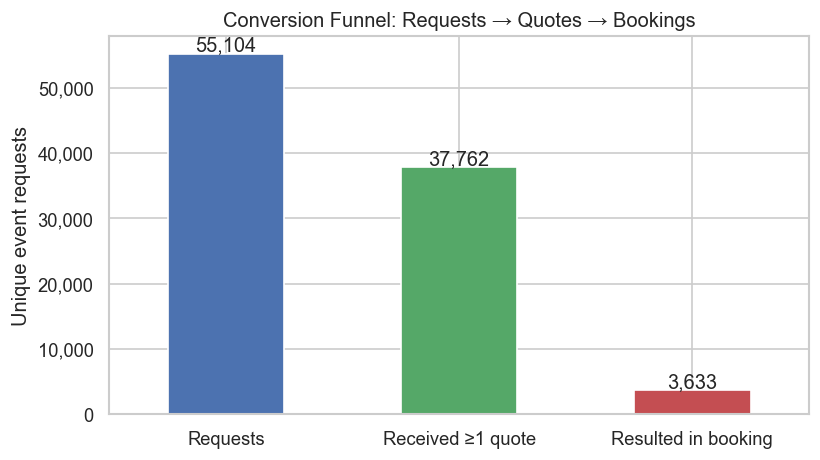

Quote coverage rate: 68.5%
Booking rate (of quoted): 9.6%
Overall conversion (request → booking): 6.6%


In [ ]:
total_requests   = requests['event_request_id'].nunique()
quoted_requests  = quotes['event_request_id'].nunique()
booked_requests  = quotes[quotes['booked'] == 1]['event_request_id'].nunique()

funnel = pd.Series({
    'Requests': total_requests,
    'Received ≥1 quote': quoted_requests,
    'Resulted in booking': booked_requests,
})

fig, ax = plt.subplots(figsize=(7, 4))
funnel.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Conversion Funnel: Requests → Quotes → Bookings')
ax.set_ylabel('Unique event requests')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(funnel):
    ax.text(i, v + total_requests * 0.01, f'{v:,}', ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES + '11_conversion_funnel.png')
plt.show()

print(f'Quote coverage rate: {quoted_requests/total_requests:.1%}')
print(f'Booking rate (of quoted): {booked_requests/quoted_requests:.1%}')
print(f'Overall conversion (request → booking): {booked_requests/total_requests:.1%}')

### 3.6 Time to first quote

count    37752.0
mean        61.0
std        429.5
min          0.0
25%          0.3
50%          0.9
75%          9.3
max      10247.3
Name: hours_to_first_quote, dtype: float64


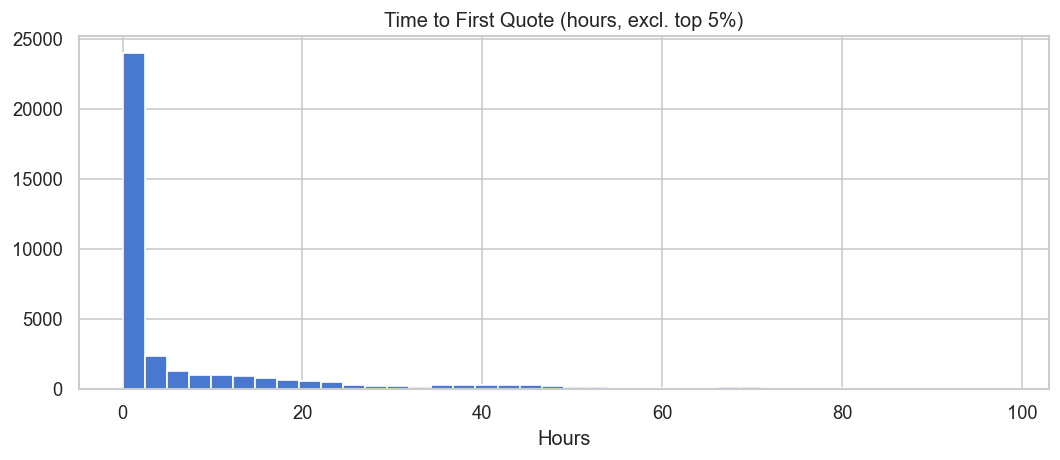

In [ ]:
first_quote = quotes.groupby('event_request_id')['quote_created'].min().rename('first_quote')
response_df = requests.set_index('event_request_id').join(first_quote).dropna(subset=['first_quote'])
response_df['hours_to_first_quote'] = (
    response_df['first_quote'] - response_df['created']
).dt.total_seconds() / 3600

# Remove negative values (data anomaly)
response_df = response_df[response_df['hours_to_first_quote'] >= 0]

print(response_df['hours_to_first_quote'].describe().round(1))

p95 = response_df['hours_to_first_quote'].quantile(0.95)
fig, ax = plt.subplots(figsize=(9, 4))
response_df[response_df['hours_to_first_quote'] <= p95]['hours_to_first_quote'].hist(bins=40, ax=ax)
ax.set_title('Time to First Quote (hours, excl. top 5%)')
ax.set_xlabel('Hours')
plt.tight_layout()
plt.savefig(FIGURES + '12_time_to_first_quote.png')
plt.show()

### 3.7 Regional conversion rates

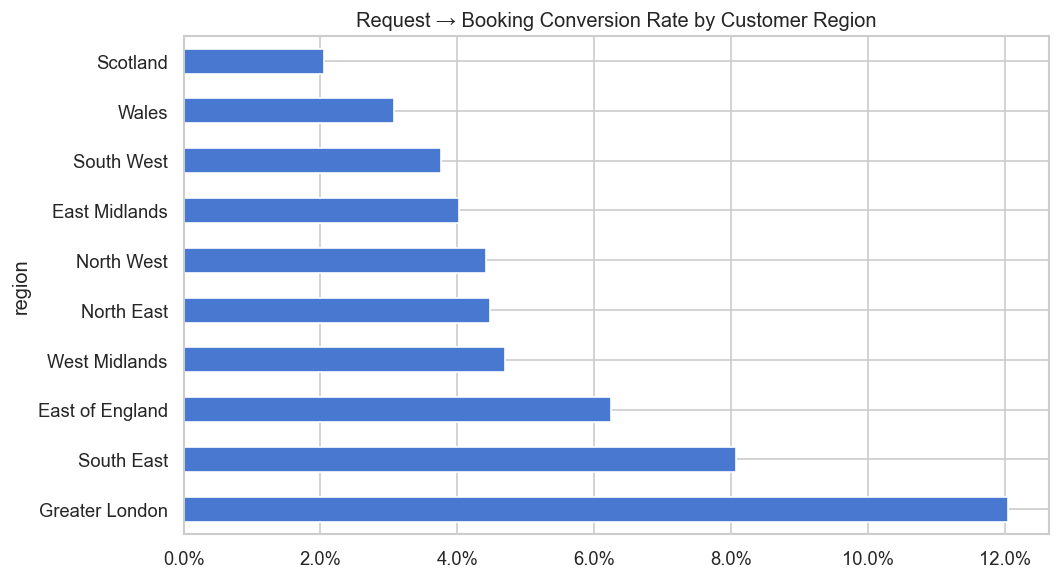

                 total_requests  bookings  conversion_rate
region                                                    
Greater London            12034    1449.0         0.120409
South East                 8904     719.0         0.080750
East of England            5831     364.0         0.062425
West Midlands              4602     216.0         0.046936
North East                 3014     135.0         0.044791
North West                 4842     214.0         0.044197
East Midlands              3309     133.0         0.040193
South West                 5950     224.0         0.037647
Wales                      1887      58.0         0.030737
Scotland                   2635      54.0         0.020493


In [ ]:
# Requests per region
req_by_region = requests.groupby('region')['event_request_id'].nunique().rename('total_requests')

# Bookings per region (customer region)
booked_per_region = (
    combined[combined['booked'] == 1]
    .groupby('region')['event_request_id'].nunique()
    .rename('bookings')
)

regional = pd.concat([req_by_region, booked_per_region], axis=1).dropna()
regional['conversion_rate'] = regional['bookings'] / regional['total_requests']
regional = regional.sort_values('conversion_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
regional['conversion_rate'].plot(kind='barh', ax=ax)
ax.set_title('Request → Booking Conversion Rate by Customer Region')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(FIGURES + '13_regional_conversion.png')
plt.show()

print(regional)

### 3.8 Tag-level conversion rates (top 15 tags by request volume)

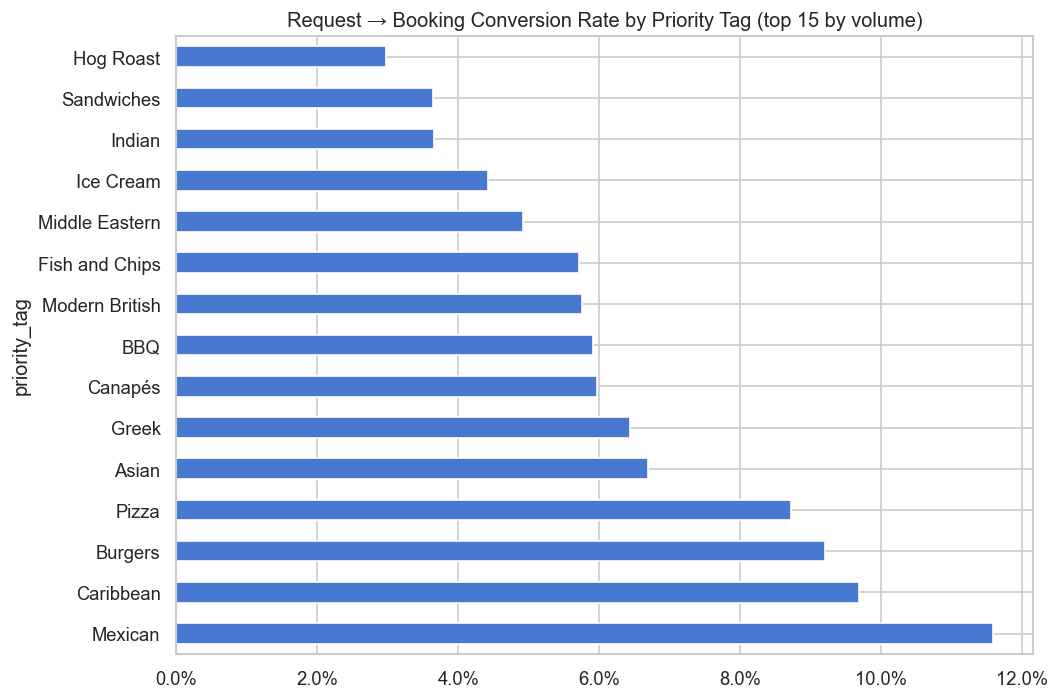

                total_requests  bookings  conversion_rate
priority_tag                                             
Mexican                   1771       205         0.115754
Caribbean                 1664       161         0.096755
Burgers                   2610       240         0.091954
Pizza                     5458       476         0.087211
Asian                     1690       113         0.066864
Greek                     1554       100         0.064350
Canapés                   1292        77         0.059598
BBQ                       6128       362         0.059073
Modern British            1998       115         0.057558
Fish and Chips            2401       137         0.057060
Middle Eastern            1057        52         0.049196
Ice Cream                 1220        54         0.044262
Indian                    2111        77         0.036476
Sandwiches                1291        47         0.036406
Hog Roast                 2357        70         0.029699


In [ ]:
top_tags = requests['priority_tag'].value_counts().head(15).index

req_by_tag = (
    requests[requests['priority_tag'].isin(top_tags)]
    .groupby('priority_tag')['event_request_id'].nunique()
    .rename('total_requests')
)

booked_by_tag = (
    combined[
        (combined['booked'] == 1) &
        (combined['priority_tag'].isin(top_tags))
    ]
    .groupby('priority_tag')['event_request_id'].nunique()
    .rename('bookings')
)

tag_conv = pd.concat([req_by_tag, booked_by_tag], axis=1).fillna(0)
tag_conv['conversion_rate'] = tag_conv['bookings'] / tag_conv['total_requests']
tag_conv = tag_conv.sort_values('conversion_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
tag_conv['conversion_rate'].plot(kind='barh', ax=ax)
ax.set_title('Request → Booking Conversion Rate by Priority Tag (top 15 by volume)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(FIGURES + '14_tag_conversion.png')
plt.show()

print(tag_conv)

---
## Summary of Data Quality Issues

| Issue | Table | Impact |
|-------|-------|--------|
| Junk header row (file name in row 0) | Requests | Must load with `header=1` |
| Null `region` values | Requests | Affects regional analysis; flag in slides |
| Encoding error on `Crêpes` tag | Quotes | Tag matching may undercount; normalise on load |
| Negative time-to-first-quote values | Combined | Quote timestamp precedes request timestamp — data anomaly |

---
## Key Findings Summary

In [ ]:
# ── Data shape ──────────────────────────────────────────────────────────────
n_requests  = len(requests)
n_quotes    = len(quotes)
n_suppliers = quotes['supplier_id'].nunique()

# ── Duplicates ───────────────────────────────────────────────────────────────
dup_requests = n_requests - requests['event_request_id'].nunique()
dup_quotes   = n_quotes   - quotes['quote_id'].nunique()

# ── Nulls ────────────────────────────────────────────────────────────────────
null_region   = requests['region'].isnull().sum()
null_priority = requests['priority_tag'].isnull().sum()
null_sup_tag  = quotes['supplier_primary_tag'].isnull().sum()

# ── Skewness ─────────────────────────────────────────────────────────────────
skew_budget = requests['request_budget'].skew()
skew_price  = quotes['quote_price'].skew()

# ── Cardinality ──────────────────────────────────────────────────────────────
n_regions       = requests['region'].nunique()
n_priority_tags = requests['priority_tag'].nunique()
n_supplier_tags = quotes['supplier_primary_tag'].nunique()

# ── Time series gaps ─────────────────────────────────────────────────────────
weekly_q    = quotes.set_index('quote_created').resample('W')['quote_id'].count()
n_gap_weeks = (weekly_q < weekly_q.mean() * 0.5).sum()

# ── Booking funnel ───────────────────────────────────────────────────────────
total_req    = requests['event_request_id'].nunique()
quoted_req   = quotes['event_request_id'].nunique()
booked_req   = quotes[quotes['booked'] == 1]['event_request_id'].nunique()
booking_rate = quotes['booked'].mean()
coverage     = quoted_req / total_req

# ── Budget vs price ──────────────────────────────────────────────────────────
_merged = quotes.merge(
    requests[['event_request_id', 'request_budget']], on='event_request_id', how='left'
).dropna(subset=['request_budget'])
pct_above_budget  = (_merged['quote_price'] > _merged['request_budget']).mean()
corr_budget_price = _merged[['request_budget', 'quote_price']].corr().iloc[0, 1]

# ── Tag match ────────────────────────────────────────────────────────────────
_combined     = requests.merge(quotes, on='event_request_id', how='left')
_tagged       = _combined.dropna(subset=['priority_tag', 'supplier_primary_tag'])
tag_match_rate = (_tagged['priority_tag'] == _tagged['supplier_primary_tag']).mean()

# ── Print summary ─────────────────────────────────────────────────────────────
sep = "=" * 55
div = "-" * 55

print(sep)
print("  EDA KEY FINDINGS SUMMARY")
print(sep)

print("\n  DATA SHAPE")
print(div)
print(f"  Event requests:           {n_requests:>8,}")
print(f"  Quotes:                   {n_quotes:>8,}  (~{n_quotes/n_requests:.1f}x per request)")
print(f"  Unique suppliers:         {n_suppliers:>8,}")

print("\n  DATA QUALITY")
print(div)
print(f"  Duplicate request IDs:    {dup_requests}")
print(f"  Duplicate quote IDs:      {dup_quotes}")
print(f"  Null region (requests):   {null_region:,}  ({null_region/n_requests:.1%})")
print(f"  Null priority_tag:        {null_priority:,}  ({null_priority/n_requests:.1%})")
print(f"  Null supplier_primary_tag:{null_sup_tag:,}  ({null_sup_tag/n_quotes:.1%})")
print(f"  Gap weeks (<50% avg vol): {n_gap_weeks}")

print("\n  DISTRIBUTIONS")
print(div)
print(f"  Unique customer regions:  {n_regions}")
print(f"  Unique priority tags:     {n_priority_tags}")
print(f"  Unique supplier tags:     {n_supplier_tags}")
print(f"  Budget skewness:          {skew_budget:.1f}  (very right-skewed)")
print(f"  Quote price skewness:     {skew_price:.1f}  (very right-skewed)")

print("\n  FUNNEL")
print(div)
print(f"  Total requests:           {total_req:,}")
print(f"  Requests with >=1 quote:  {quoted_req:,}  ({coverage:.1%} coverage)")
print(f"  Requests with a booking:  {booked_req:,}  ({booked_req/total_req:.1%} overall)")
print(f"  Quote -> booking rate:    {booking_rate:.2%}")

print("\n  PRICING")
print(div)
print(f"  Quotes above budget:      {pct_above_budget:.1%}")
print(f"  Corr(budget, price):      {corr_budget_price:.3f}  (weak)")

print("\n  MATCHING")
print(div)
print(f"  Customer/supplier tag match: {tag_match_rate:.1%}")

print(sep)